In [1]:
import pandas as pd

df = pd.read_csv("diamonds.csv")
print("Original shape:", df.shape)

Original shape: (50000, 10)


In [8]:
print(df.head())
print("Final shape:", df.shape)
print(df.dtypes)

   carat  depth  table  price     x     y     z  cut_encoded  color_encoded  \
0   0.23   61.5   55.0    326  3.95  3.98  2.43            5              6   
1   0.21   59.8   61.0    326  3.89  3.84  2.31            4              6   
2   0.23   56.9   65.0    327  4.05  4.07  2.31            2              6   
3   0.29   62.4   58.0    334  4.20  4.23  2.63            4              2   
4   0.31   63.3   58.0    335  4.34  4.35  2.75            2              1   

   clarity_encoded  
0                2  
1                3  
2                5  
3                4  
4                2  
Final shape: (49857, 10)
carat              float64
depth              float64
table              float64
price                int64
x                  float64
y                  float64
z                  float64
cut_encoded          int64
color_encoded        int64
clarity_encoded      int64
dtype: object


In [12]:
df.describe()

,carat,depth,table,price,x,y,z,cut_encoded,color_encoded,clarity_encoded
count,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000,49857.000000
mean,0.799101,61.751884,57.458521,3943.651042,5.734907,5.738407,3.542236,3.902742,4.401669,4.048880
std,0.474403,1.427981,2.230608,3994.952489,1.120144,1.143127,0.703695,1.116179,1.700745,1.643196
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000,1.000000,1.000000,1.000000
25%,0.400000,61.000000,56.000000,952.000000,4.720000,4.720000,2.910000,3.000000,3.000000,3.000000
50%,0.700000,61.800000,57.000000,2411.000000,5.700000,5.710000,3.530000,4.000000,4.000000,4.000000
75%,1.040000,62.500000,59.000000,5351.000000,6.540000,6.540000,4.040000,5.000000,6.000000,5.000000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000,5.000000,7.000000,8.000000


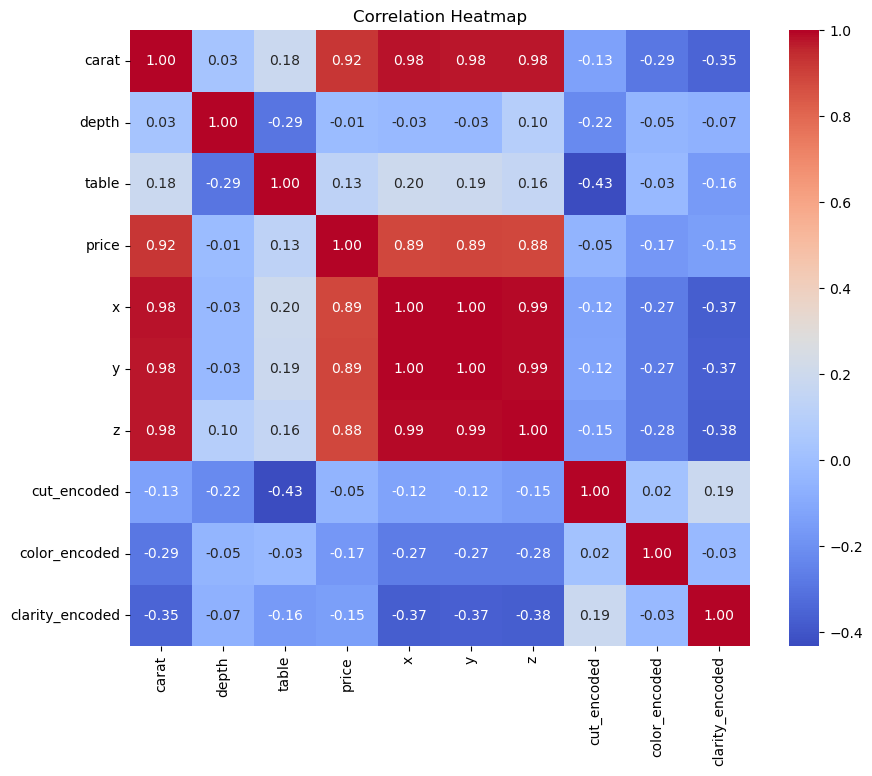

In [32]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [41]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [42]:
df = pd.read_csv("diamonds_cleaned.csv")
print(df.shape)
df.head()

(49851, 10)


,carat,depth,table,price,x,y,z,cut_encoded,color_encoded,clarity_encoded
0,0.23,61.5,55.0,326,3.95,3.98,2.43,5,6,2
1,0.21,59.8,61.0,326,3.89,3.84,2.31,4,6,3
2,0.23,56.9,65.0,327,4.05,4.07,2.31,2,6,5
3,0.29,62.4,58.0,334,4.20,4.23,2.63,4,2,4
4,0.31,63.3,58.0,335,4.34,4.35,2.75,2,1,2


In [43]:
features = df.drop(columns=["price"])
features.head()

,carat,depth,table,x,y,z,cut_encoded,color_encoded,clarity_encoded
0,0.23,61.5,55.0,3.95,3.98,2.43,5,6,2
1,0.21,59.8,61.0,3.89,3.84,2.31,4,6,3
2,0.23,56.9,65.0,4.05,4.07,2.31,2,6,5
3,0.29,62.4,58.0,4.20,4.23,2.63,4,2,4
4,0.31,63.3,58.0,4.34,4.35,2.75,2,1,2


In [44]:
features_with_const = add_constant(features)
features_with_const.head()

,const,carat,depth,table,x,y,z,cut_encoded,color_encoded,clarity_encoded
0,1.0,0.23,61.5,55.0,3.95,3.98,2.43,5,6,2
1,1.0,0.21,59.8,61.0,3.89,3.84,2.31,4,6,3
2,1.0,0.23,56.9,65.0,4.05,4.07,2.31,2,6,5
3,1.0,0.29,62.4,58.0,4.20,4.23,2.63,4,2,4
4,1.0,0.31,63.3,58.0,4.34,4.35,2.75,2,1,2


In [45]:
vif_data = pd.DataFrame()
vif_data["feature"] = features_with_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(features_with_const.values, i)
    for i in range(features_with_const.shape[1])
]

In [46]:
vif_data = vif_data[vif_data["feature"] != "const"]
vif_data = vif_data.sort_values(by="VIF", ascending=False)
vif_data

,feature,VIF
6,z,884.853312
5,y,643.666523
4,x,596.147891
1,carat,25.097771
2,depth,14.721902
3,table,1.626273
7,cut_encoded,1.505608
9,clarity_encoded,1.236523
8,color_encoded,1.120640


In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [48]:
df = pd.read_csv("diamonds_cleaned.csv")
print(df.shape)
df.head()

(49851, 10)


,carat,depth,table,price,x,y,z,cut_encoded,color_encoded,clarity_encoded
0,0.23,61.5,55.0,326,3.95,3.98,2.43,5,6,2
1,0.21,59.8,61.0,326,3.89,3.84,2.31,4,6,3
2,0.23,56.9,65.0,327,4.05,4.07,2.31,2,6,5
3,0.29,62.4,58.0,334,4.20,4.23,2.63,4,2,4
4,0.31,63.3,58.0,335,4.34,4.35,2.75,2,1,2


In [49]:
X = df.drop(columns=["price"])
y = df["price"]

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (39880, 9)
Test shape: (9971, 9)


In [51]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [52]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train_log)

linear_pred_log = linear_model.predict(X_test_scaled)
linear_pred = np.expm1(linear_pred_log)

In [54]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train_log)

ridge_pred_log = ridge_model.predict(X_test_scaled)
ridge_pred = np.expm1(ridge_pred_log)

In [55]:
lasso_model = Lasso(alpha=0.001, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train_log)

lasso_pred_log = lasso_model.predict(X_test_scaled)
lasso_pred = np.expm1(lasso_pred_log)

In [56]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [57]:
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}")
    return {"Model": model_name, "RMSE": rmse, "MAE": mae, "R2": r2}

In [58]:
results = []
results.append(evaluate(y_test, linear_pred, "Linear Regression"))
results.append(evaluate(y_test, ridge_pred, "Ridge Regression"))
results.append(evaluate(y_test, lasso_pred, "Lasso Regression"))
results.append(evaluate(y_test, rf_pred, "Random Forest"))

Linear Regression -> RMSE: 855.53, MAE: 454.89, R2: 0.9530
Ridge Regression -> RMSE: 855.58, MAE: 454.85, R2: 0.9530
Lasso Regression -> RMSE: 875.83, MAE: 459.65, R2: 0.9507
Random Forest -> RMSE: 529.04, MAE: 263.48, R2: 0.9820


In [59]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2", ascending=False)
results_df

,Model,RMSE,MAE,R2
3,Random Forest,529.041733,263.484262,0.982017
0,Linear Regression,855.533701,454.885512,0.952972
1,Ridge Regression,855.580830,454.848418,0.952966
2,Lasso Regression,875.831868,459.651601,0.950713


In [60]:
feature_names = X.columns

In [61]:
linear_coefs = linear_model.coef_
ridge_coefs = ridge_model.coef_
lasso_coefs = lasso_model.coef_

In [62]:
coef_comparison = pd.DataFrame({
    "Feature": feature_names,
    "Linear": linear_coefs,
    "Ridge": ridge_coefs,
    "Lasso": lasso_coefs
})

coef_comparison

,Feature,Linear,Ridge,Lasso
0,carat,-0.529617,-0.528916,-0.480099
1,depth,0.027873,0.027879,0.016807
2,table,0.022014,0.022032,0.018521
3,x,0.666023,0.663139,0.590786
4,y,0.418711,0.421142,0.398526
5,z,0.523800,0.523540,0.569037
6,cut_encoded,0.031073,0.031086,0.028172
7,color_encoded,0.132475,0.132481,0.131890
8,clarity_encoded,0.198379,0.198343,0.195713


In [63]:
coef_comparison["Linear_abs"] = coef_comparison["Linear"].abs()
coef_comparison = coef_comparison.sort_values(by="Linear_abs", ascending=False)
coef_comparison = coef_comparison.drop(columns=["Linear_abs"])
coef_comparison

,Feature,Linear,Ridge,Lasso
3,x,0.666023,0.663139,0.590786
0,carat,-0.529617,-0.528916,-0.480099
5,z,0.523800,0.523540,0.569037
4,y,0.418711,0.421142,0.398526
8,clarity_encoded,0.198379,0.198343,0.195713
7,color_encoded,0.132475,0.132481,0.131890
6,cut_encoded,0.031073,0.031086,0.028172
1,depth,0.027873,0.027879,0.016807
2,table,0.022014,0.022032,0.018521


In [64]:
print(list(X.columns))
print(list(X_train.columns))

['carat', 'depth', 'table', 'x', 'y', 'z', 'cut_encoded', 'color_encoded', 'clarity_encoded']
['carat', 'depth', 'table', 'x', 'y', 'z', 'cut_encoded', 'color_encoded', 'clarity_encoded']


In [65]:
X_train_carat_only = X_train[["carat"]]
X_test_carat_only = X_test[["carat"]]

In [66]:
scaler_check = StandardScaler()
X_train_carat_scaled = scaler_check.fit_transform(X_train_carat_only)

In [67]:
check_model = LinearRegression()
check_model.fit(X_train_carat_scaled, y_train_log)

print("Carat coefficient (alone, no other features):", check_model.coef_[0])

Carat coefficient (alone, no other features): 0.9339648749575387


In [68]:
ridge_strong = Ridge(alpha=100.0)
ridge_strong.fit(X_train_scaled, y_train_log)

,alpha,100.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [69]:
print("Ridge (alpha=100) carat coef:", ridge_strong.coef_[0])
print("Ridge (alpha=100) x coef:", ridge_strong.coef_[3])

Ridge (alpha=100) carat coef: -0.46766774311754233
Ridge (alpha=100) x coef: 0.5539456910633762


In [70]:
lasso_strong = Lasso(alpha=0.05, max_iter=10000)
lasso_strong.fit(X_train_scaled, y_train_log)

,alpha,0.05
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,10000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [71]:
print("Lasso (alpha=0.05) carat coef:", lasso_strong.coef_[0])
print("Lasso (alpha=0.05) x coef:", lasso_strong.coef_[3])

Lasso (alpha=0.05) carat coef: 0.0
Lasso (alpha=0.05) x coef: 0.2237564024516333


In [72]:
strong_lasso_coefs = pd.DataFrame({
    "Feature": feature_names,
    "Lasso (alpha=0.05)": lasso_strong.coef_
})
strong_lasso_coefs

,Feature,Lasso (alpha=0.05)
0,carat,0.000000
1,depth,0.000000
2,table,-0.000000
3,x,0.223756
4,y,0.472236
5,z,0.287024
6,cut_encoded,0.000000
7,color_encoded,0.062262
8,clarity_encoded,0.100325


In [73]:
ridge_strong_pred = np.expm1(ridge_strong.predict(X_test_scaled))
lasso_strong_pred = np.expm1(lasso_strong.predict(X_test_scaled))

evaluate(y_test, ridge_strong_pred, "Ridge (alpha=100)")
evaluate(y_test, lasso_strong_pred, "Lasso (alpha=0.05)")

Ridge (alpha=100) -> RMSE: 879.63, MAE: 459.56, R2: 0.9503
Lasso (alpha=0.05) -> RMSE: 1831.38, MAE: 740.80, R2: 0.7845


{'Model': 'Lasso (alpha=0.05)',
 'RMSE': np.float64(1831.3809229344324),
 'MAE': 740.8000502435324,
 'R2': 0.78450163730572}

In [74]:
from sklearn.linear_model import RidgeCV

alphas_to_try = [0.01, 0.1, 1, 10, 50, 100, 200, 500]
ridge_cv = RidgeCV(alphas=alphas_to_try, cv=5)
ridge_cv.fit(X_train_scaled, y_train_log)

print("Best alpha:", ridge_cv.alpha_)
print("Carat coef:", ridge_cv.coef_[0])

Best alpha: 10.0
Carat coef: -0.5227336386251608


In [75]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas=[0.0001, 0.0005, 0.001, 0.005, 0.01, 0.02, 0.05], cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train_log)

print("Best alpha:", lasso_cv.alpha_)
print("Carat coef:", lasso_cv.coef_[0])

Best alpha: 0.0001
Carat coef: -0.5245590912445759


In [76]:
X_reduced = X.drop(columns=["x", "y", "z"])
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

y_train_r_log = np.log1p(y_train_r)

reduced_model = LinearRegression()
reduced_model.fit(X_train_r_scaled, y_train_r_log)

print("Carat coefficient (no x/y/z in model):", reduced_model.coef_[0])

Carat coefficient (no x/y/z in model): 1.0309557106944787


In [77]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importances = importances.sort_values(by="Importance", ascending=False)
importances

,Feature,Importance
0,carat,0.485414
4,y,0.401791
8,clarity_encoded,0.062783
7,color_encoded,0.030894
5,z,0.006217
3,x,0.005925
1,depth,0.003025
2,table,0.002289
6,cut_encoded,0.001663


In [78]:
from sklearn.linear_model import ElasticNet, ElasticNetCV

In [79]:
elastic_model = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)
elastic_model.fit(X_train_scaled, y_train_log)

elastic_pred_log = elastic_model.predict(X_test_scaled)
elastic_pred = np.expm1(elastic_pred_log)

In [80]:
evaluate(y_test, elastic_pred, "Elastic Net (baseline)")

Elastic Net (baseline) -> RMSE: 867.65, MAE: 457.16, R2: 0.9516


{'Model': 'Elastic Net (baseline)',
 'RMSE': np.float64(867.6548150166882),
 'MAE': 457.1585087291633,
 'R2': 0.9516295012507314}

In [81]:
l1_ratios_to_try = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]

elastic_cv = ElasticNetCV(
    l1_ratio=l1_ratios_to_try,
    alphas=[0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05],
    cv=5,
    max_iter=10000
)
elastic_cv.fit(X_train_scaled, y_train_log)

print("Best alpha:", elastic_cv.alpha_)
print("Best l1_ratio:", elastic_cv.l1_ratio_)

Best alpha: 0.0005
Best l1_ratio: 0.1


In [82]:
print("Elastic Net (CV-tuned) carat coef:", elastic_cv.coef_[0])
print("Elastic Net (CV-tuned) x coef:", elastic_cv.coef_[3])
print("Elastic Net (CV-tuned) y coef:", elastic_cv.coef_[4])
print("Elastic Net (CV-tuned) z coef:", elastic_cv.coef_[5])

Elastic Net (CV-tuned) carat coef: -0.5149235401650031
Elastic Net (CV-tuned) x coef: 0.6218122300404328
Elastic Net (CV-tuned) y coef: 0.4480795880787786
Elastic Net (CV-tuned) z coef: 0.5237139695512081


In [83]:
elastic_cv_pred = np.expm1(elastic_cv.predict(X_test_scaled))
evaluate(y_test, elastic_cv_pred, "Elastic Net (CV-tuned)")

Elastic Net (CV-tuned) -> RMSE: 858.31, MAE: 454.96, R2: 0.9527


{'Model': 'Elastic Net (CV-tuned)',
 'RMSE': np.float64(858.3081134337375),
 'MAE': 454.9646860455328,
 'R2': 0.9526660182839719}

In [84]:
full_coef_comparison = pd.DataFrame({
    "Feature": feature_names,
    "Linear": linear_coefs,
    "Ridge (CV)": ridge_cv.coef_,
    "Lasso (CV)": lasso_cv.coef_,
    "Elastic Net (CV)": elastic_cv.coef_
})

full_coef_comparison

,Feature,Linear,Ridge (CV),Lasso (CV),Elastic Net (CV)
0,carat,-0.529617,-0.522734,-0.524559,-0.514924
1,depth,0.027873,0.027862,0.030161,0.027081
2,table,0.022014,0.022147,0.021942,0.022025
3,x,0.666023,0.641098,0.646481,0.621812
4,y,0.418711,0.438806,0.454610,0.448080
5,z,0.523800,0.521626,0.502169,0.523714
6,cut_encoded,0.031073,0.031168,0.030967,0.031064
7,color_encoded,0.132475,0.132534,0.132418,0.132551
8,clarity_encoded,0.198379,0.198045,0.197994,0.197675


In [85]:
results.append(evaluate(y_test, elastic_cv_pred, "Elastic Net (CV-tuned)"))

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2", ascending=False)
results_df

Elastic Net (CV-tuned) -> RMSE: 858.31, MAE: 454.96, R2: 0.9527


,Model,RMSE,MAE,R2
3,Random Forest,529.041733,263.484262,0.982017
0,Linear Regression,855.533701,454.885512,0.952972
1,Ridge Regression,855.580830,454.848418,0.952966
4,Elastic Net (CV-tuned),858.308113,454.964686,0.952666
2,Lasso Regression,875.831868,459.651601,0.950713


In [86]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [87]:
df = pd.read_csv("diamonds_cleaned.csv")
print(df.shape)

(49851, 10)


In [88]:
X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (39880, 9)
Test shape: (9971, 9)


In [89]:
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.4f}")
    return {"Model": model_name, "RMSE": rmse, "MAE": mae, "R2": r2}

In [90]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

In [92]:
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=10,        # was 20
    cv=2,              # was 3
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

In [94]:
rf_search.fit(X_train, y_train)
print("Best parameters:", rf_search.best_params_)

Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}


In [95]:
rf_best = rf_search.best_estimator_
rf_best_pred = rf_best.predict(X_test)

evaluate(y_test, rf_best_pred, "Random Forest (tuned)")

Random Forest (tuned) -> RMSE: 527.50, MAE: 262.69, R2: 0.9821


{'Model': 'Random Forest (tuned)',
 'RMSE': np.float64(527.4982270899454),
 'MAE': 262.69440365676024,
 'R2': 0.9821216015669281}

In [3]:
import os
os.makedirs("results", exist_ok=True)

In [5]:
import pandas as pd

results_df = pd.DataFrame([
    {"Model": "Random Forest (tuned)", "RMSE": 527.50, "MAE": 262.69, "R2": 0.9821},
    {"Model": "Linear Regression", "RMSE": 855.53, "MAE": 454.89, "R2": 0.9530},
    {"Model": "Ridge Regression (CV-tuned)", "RMSE": 855.58, "MAE": 454.85, "R2": 0.9530},
    {"Model": "Elastic Net (CV-tuned)", "RMSE": 858.31, "MAE": 454.96, "R2": 0.9527},
    {"Model": "Lasso Regression (CV-tuned)", "RMSE": 876.00, "MAE": 460.00, "R2": 0.9507},
])

results_df = results_df.sort_values(by="R2", ascending=False)
results_df.to_csv("results/model_comparison.csv", index=False)
print(results_df)

                         Model    RMSE     MAE      R2
0        Random Forest (tuned)  527.50  262.69  0.9821
1            Linear Regression  855.53  454.89  0.9530
2  Ridge Regression (CV-tuned)  855.58  454.85  0.9530
3       Elastic Net (CV-tuned)  858.31  454.96  0.9527
4  Lasso Regression (CV-tuned)  876.00  460.00  0.9507
